# Fitting Conductivity with Streched Exponentials

Author: [Rylan Stutters](https://github.com/RylanDS7)

Notebook to fit the cole-cole conductivity model to stretched exponential functions under a step down response

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from simpeg import *
import numpy as np
import matplotlib.pyplot as plt
from discretize import TensorMesh
from EMIP import SEInv

In [2]:
# cole cole function
def ColeColeSeigel(f, sigmaInf, eta, tau, c):
    w = 2*np.pi*f
    return sigmaInf*(1 - eta/(1 + (1j*w*tau)**c))

In [3]:
# CC SE function for step off
def ColeSEImpulsefun(eta, tau, c, time):
    return eta*c/time*((time/tau)**c)*np.exp(-(time/tau)**c)

In [4]:
# obtain predicted behavior via Hankel Transform with cos filters
# TODO Review/update
def predictSE(sigmaInf, eta, tau, c):
    from utils import DigFilter # module to be deprecated

    t = np.logspace(-6,np.log10(0.01), 41)
    wt, tbase, omega_int = DigFilter.setFrequency(t)
    f = omega_int / (2*np.pi)

    CC = ColeColeSeigel(f, sigmaInf, eta, tau, c)
    sigTCole = -DigFilter.transFiltImpulse(CC, wt, tbase, omega_int, t, tol=1e-12) # not sure why this has to be negative

    return sigTCole, t


In [27]:
# fit SE parameters with SimPEG inversion
def fitSEparam(obsData, mCC0, t):
    dtrue = obsData
    survey = SEInv.SESurvey(t)
    sim = SEInv.SEInvProblem(survey=survey)
    data_obj = data.Data(survey=survey, dobs=dtrue, standard_deviation=0.001)

    misfit = data_misfit.L2DataMisfit(data=data_obj, simulation=sim)
    mesh = TensorMesh([3])
    reg = regularization.Smallness(mesh)
    opt = optimization.InexactGaussNewton(maxIter=20)

    inv_prob = inverse_problem.BaseInvProblem(misfit, reg, opt)
    inv = inversion.BaseInversion(inv_prob)

    mrec = inv.run(mCC0)

    print("Recovered model:", mrec)

    return mrec

In [31]:
eta1, tau1, c1 = 0.1, 1e-3, 0.5
mCC = np.array([eta1, tau1, c1])

obsSigma, t = predictSE(1, eta1, tau1, c1)

mSE = fitSEparam(obsSigma, mCC, t)
predSigma = ColeSEImpulsefun(mSE[0], mSE[1], mSE[2], t)

INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Pardiso with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
[0.1   0.001 0.5  ]
   0  1.00e+00  8.71e+10  0.00e+00  8.71e+10                                 
[0.10000381 0.00081729 0.49999844]
   1  1.00e+00  7.41e+09  1.11e-08  7.41e+09    8.91e+14      0              
[0.10000342 0.00083822 0.49999853]
   2  1.00e+00  5.50e+09  8.73e-09  5.50e+09    1.83e+14      0              
[6.90501724e-02 3.44048513e-04 4.91480547e-01]
[0.0845268  0.00059114 0.49573954]
   3  1.00e+00  2.38e+09  8.59e-05  2.38e+09    3.52e+12      1              
[0.08593525 0.00063059 0.49437731]
   4  1.00e+00  1.14e+09  7.65e-05  1.14e+09    1.97e+14      0              
[0.07680489 0.00050683 0.49036625]
   5  1.00e+00  1.05e+08  2.10e-04  1.05e+08    1.72e+13      0              
[0.07696258 0.00

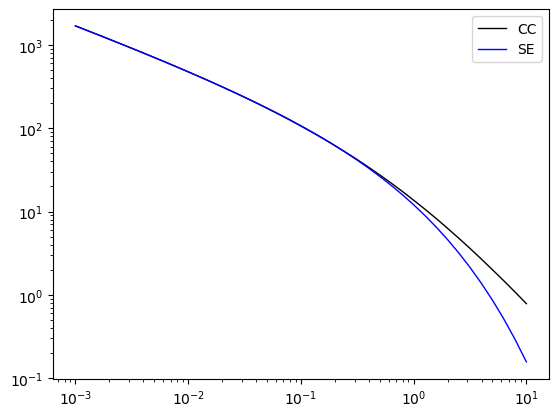

In [32]:
plt.loglog(t*1e3, obsSigma, 'k', lw=1, label='CC')
plt.loglog(t*1e3, predSigma, 'b', lw=1, label='SE')
plt.legend()